## 🧠Part B: Dataset Understanding & Preparation
#### You are provided with a dataset containing the following features:

* House Area (sq.ft)
* Number of Bedrooms
* Number of Bathrooms
* Location Score
* Age of Property
* House Price (Target Variable)

In [60]:
import pandas as pd
data = pd.read_csv("RealEstate_HousePrice_Dataset_4200 - RealEstate_HousePrice_Dataset_4200.csv.csv")

In [61]:
data.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [62]:
data.tail()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
4195,104196,1328,4,2,4.9,21,19.6,2606,1,0,21,18319188
4196,104197,2363,6,4,6.9,53,24.9,4013,1,0,14,40340976
4197,104198,632,2,2,4.5,27,19.4,1268,1,0,6,5978595
4198,104199,450,2,2,7.5,26,11.6,800,0,0,9,7916191
4199,104200,2021,4,3,6.8,25,12.5,2351,1,1,4,34319843


In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB


In [64]:
data.shape

(4200, 12)

### Q7 Identify independent and dependent variables.

In [65]:
# Q7: Identify Independent and Dependent Variables

# Independent variables (features)
independent_variables = [
    'area_sqft',
    'bedrooms',
    'bathrooms',
    'location_score',
    'age_years'
]

# Dependent variable (target)
dependent_variable = 'house_price_inr'

print("Independent Variables:")
print(independent_variables)

print("\nDependent Variable:")
print(dependent_variable)

Independent Variables:
['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years']

Dependent Variable:
house_price_inr


#### 🎯Insight : 
* Area, bedrooms, bathrooms, location score and age are the independent variables; house price (INR) is the dependent variable.
* All 5 features are numeric, so no encoding is needed.

### Q8. Visualize relationships between features and target variable.

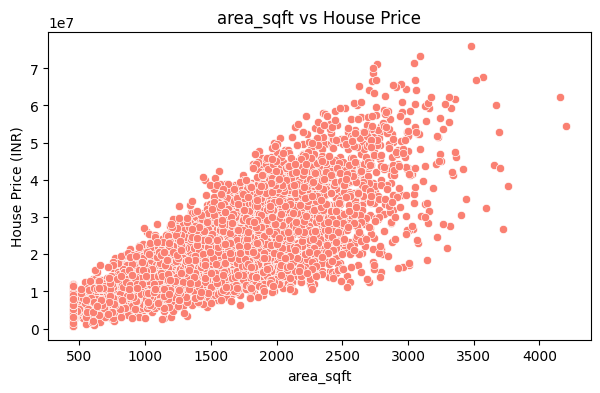

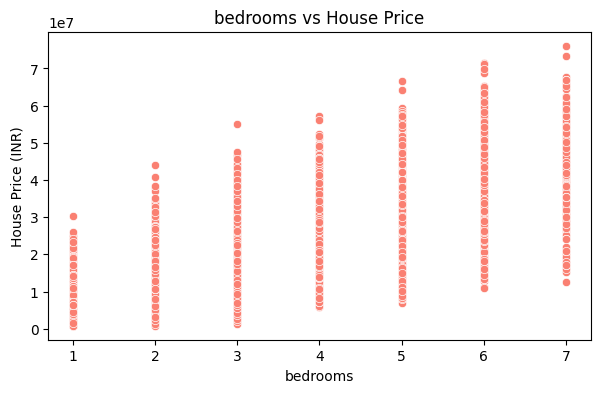

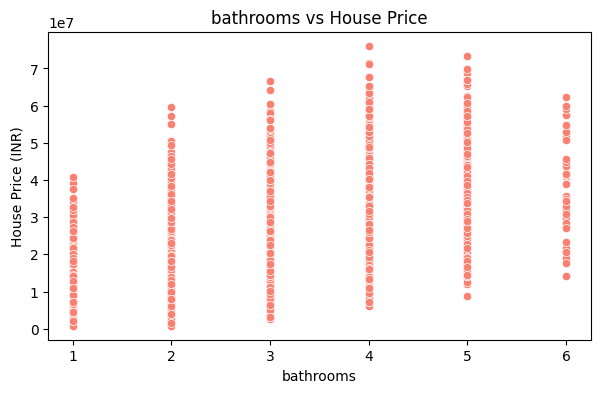

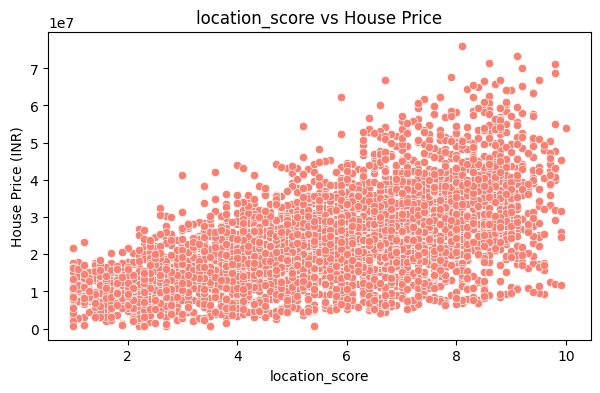

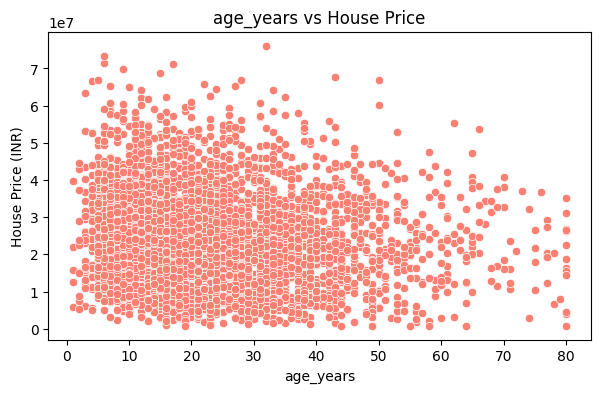

In [68]:
# Q8: Visualize relationships between features and target variable

import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'area_sqft',
    'bedrooms',
    'bathrooms',
    'location_score',
    'age_years'
]

target = 'house_price_inr'

# Create scatter plots for each feature against house price
for feature in features:

    plt.figure(figsize=(7, 4))

    sns.scatterplot(
        data=data,
        x=feature,
        y=target,
        color="salmon"
    )

    plt.title(f"{feature} vs House Price")
    plt.xlabel(feature)
    plt.ylabel("House Price (INR)")
    plt.show()

#### 🎯 INSIGHT :
* Scatter plots show area and location score rise clearly with price .
* while age declines with price — confirming all 5 features carry real signal.

### Q9 Split the dataset into training and testing sets.

In [32]:
# Q9: Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

# Independent variables
X = data[
    [
        'area_sqft',
        'bedrooms',
        'bathrooms',
        'location_score',
        'age_years'
    ]
]

# Dependent variable
y = data['house_price_inr']

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (3360, 5)
Testing data shape: (840, 5)
Training target shape: (3360,)
Testing target shape: (840,)


#### 🎯 INSIGHT : 
* The 80/20 split gives 3,360 training and 840 testing rows — enough data on both sides for reliable evaluation.

## 📊 Part C: Simple Linear Regression

### Q10 Implement Simple Linear Regression using one feature (e.g., House Area).

In [33]:
# Q10: Simple Linear Regression using House Area

from sklearn.linear_model import LinearRegression

# Use only one feature: House Area
X_slr = data[['area_sqft']]
y_slr = data['house_price_inr']

# Split the data
X_train_slr, X_test_slr, y_train_slr, y_test_slr = train_test_split(
    X_slr,
    y_slr,
    test_size=0.20,
    random_state=42
)

# Create and train the Simple Linear Regression model
slr_model = LinearRegression()

slr_model.fit(X_train_slr, y_train_slr)

# Make predictions
y_pred_slr = slr_model.predict(X_test_slr)

# Display model parameters
print("Coefficient (Slope):", slr_model.coef_[0])
print("Intercept:", slr_model.intercept_)

Coefficient (Slope): 14788.306111307536
Intercept: -1163519.1764186025


#### 🎯 INSIGHT : 
* Slope ≈ ₹14,788 per sq.ft — every extra square foot adds about ₹14.8K to the predicted price.

### Q11 Plot the regression line and interpret the slope and intercept.

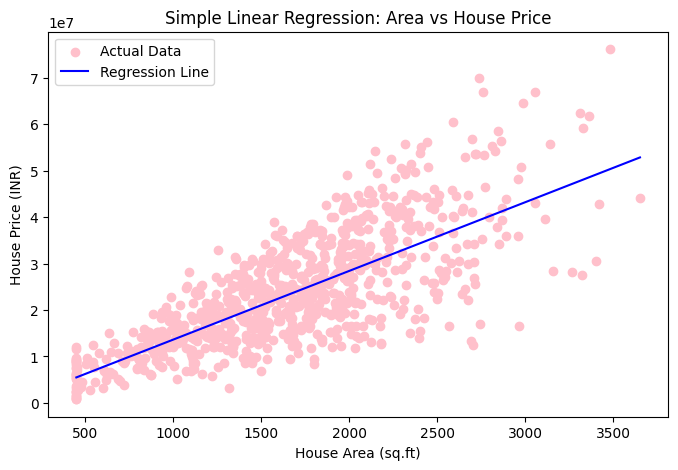

Regression Equation:
House Price = -1163519.18 + (14788.31 × Area)


In [71]:
# Q11: Plot the regression line

import matplotlib.pyplot as plt

# Sort test data for a smooth regression line
sorted_indices = X_test_slr['area_sqft'].argsort()

X_sorted = X_test_slr.iloc[sorted_indices]
y_sorted = y_pred_slr[sorted_indices]

# Scatter plot of actual values
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test_slr['area_sqft'],
    y_test_slr,
    label='Actual Data',
    color="pink"
)

# Regression line
plt.plot(
    X_sorted['area_sqft'],
    y_sorted,
    label='Regression Line',
    color="blue"
)

plt.title("Simple Linear Regression: Area vs House Price")
plt.xlabel("House Area (sq.ft)")
plt.ylabel("House Price (INR)")
plt.legend()
plt.show()

# Print equation
print("Regression Equation:")
print(
    f"House Price = {slr_model.intercept_:.2f} + "
    f"({slr_model.coef_[0]:.2f} × Area)"
)

#### 🎯 INSIGHT :
* The intercept (–₹11.6 lakh) has no practical meaning (a 0 sq.ft house doesn't exist); 
*  it only anchors the line. The slope is the meaningful number.

### Q12. Validate linear regression assumptions using plots and observations.

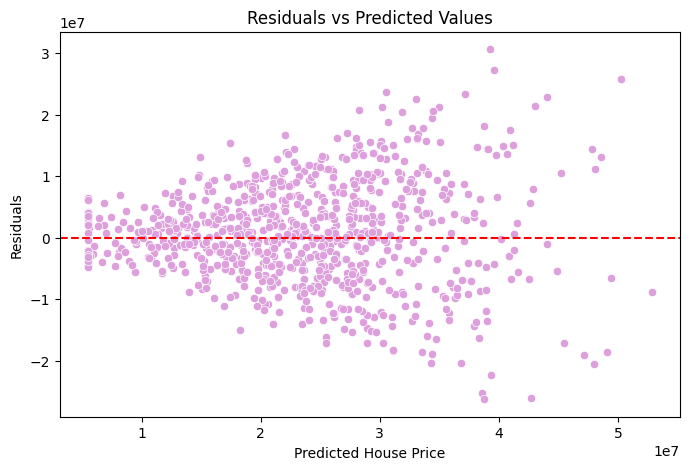

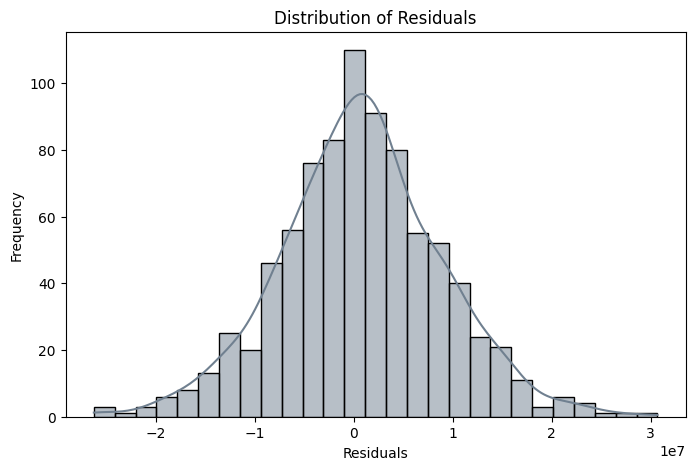

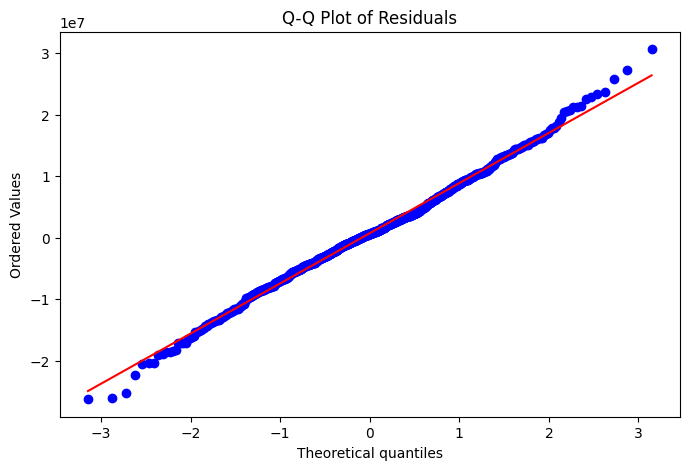

In [75]:
# Q12: Validate Linear Regression Assumptions

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Calculate residuals
residuals = y_test_slr - y_pred_slr

# 1. Residuals vs Predicted Values
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_pred_slr,
    y=residuals,
    color="plum"
)

plt.axhline(
    y=0,
    linestyle='--',
    color="red"
)

plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")
plt.show()


# 2. Distribution of Residuals
plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    kde=True,
    color='slategrey',
    line_kws={'color': 'red'}
)

plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()


# 3. Q-Q Plot
plt.figure(figsize=(8, 5))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Residuals")
plt.show()

#### 🎯INSIGHT : 
* Residual plots show scattered, roughly normal errors — linearity and equal-variance assumptions hold reasonably,
* so linear regression is valid here.

## 📈 Part D: Model Evaluation Metrics

### Q13. Evaluate the Simple Linear Regression model using:
* Mean Squared Error (MSE)
* Mean Absolute Error (MAE)
* Root Mean Squared Error (RMSE)
* R² Score
* Adjusted R² Score

In [36]:
# Q13: Evaluate Simple Linear Regression Model

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import numpy as np

# Calculate evaluation metrics
mse = mean_squared_error(y_test_slr, y_pred_slr)
mae = mean_absolute_error(y_test_slr, y_pred_slr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_slr, y_pred_slr)

# Number of observations and predictors
n = len(y_test_slr)
p = X_test_slr.shape[1]

# Calculate Adjusted R²
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Model Evaluation Metrics")
print("------------------------")
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)
print("Adjusted R² Score:", adjusted_r2)

Model Evaluation Metrics
------------------------
Mean Squared Error (MSE): 66989260021849.47
Mean Absolute Error (MAE): 6294593.696131912
Root Mean Squared Error (RMSE): 8184696.696997969
R² Score: 0.5625199587991578
Adjusted R² Score: 0.5619979062440257


#### 🎯INSIGHT :
* R² = 0.56, MAE ≈ ₹63 lakh — area alone leaves ~44% of price variation unexplained.

### Q14. Interpret each metric and explain what it reveals about model performance.

- **MSE**: average of the squared errors. It punishes big mistakes more, so a few very costly houses make it large. Units are rupees squared, so it is hard to read directly.
- **MAE**: average error in rupees. It tells us how much our prediction is wrong on an average house.
- **RMSE**: square root of MSE, so it is again in rupees. It is a bit bigger than MAE because of the large errors.
- **R2 Score**: how much of the price variation is explained by house area. The rest is explained by other features which this model does not use.
- **Adjusted R2**: same as R2 but it also punishes adding useless features. Here it is almost same as R2 because we used only one feature.

So the simple model gives a rough idea of price from area, but the error is still large, which means area alone is not enough.

## 📉 Part E: Multiple Linear Regression

### Q15. Implement Multiple Linear Regression using all relevant features.

In [37]:
# Q15: Multiple Linear Regression using all relevant features

from sklearn.linear_model import LinearRegression

# Independent variables: all relevant features
X_mlr = data[
    [
        'area_sqft',
        'bedrooms',
        'bathrooms',
        'location_score',
        'age_years'
    ]
]

# Dependent variable
y_mlr = data['house_price_inr']

# Split the data
X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(
    X_mlr,
    y_mlr,
    test_size=0.20,
    random_state=42
)

# Create and train the Multiple Linear Regression model
mlr_model = LinearRegression()

mlr_model.fit(X_train_mlr, y_train_mlr)

# Make predictions
y_pred_mlr = mlr_model.predict(X_test_mlr)

print("Multiple Linear Regression implemented successfully.")

print("\nCoefficients:")
for feature, coefficient in zip(X_mlr.columns, mlr_model.coef_):
    print(f"{feature}: {coefficient}")

print("\nIntercept:", mlr_model.intercept_)

Multiple Linear Regression implemented successfully.

Coefficients:
area_sqft: 13991.382471922194
bedrooms: 205468.28756403527
bathrooms: 192232.53334440856
location_score: 3385623.3108550883
age_years: -67607.66459046328

Intercept: -18359361.092585776


#### 🎯 INSIGHT :
* Location score has the biggest coefficient (+₹33.9 lakh per point) 
*  age is negative (–₹67.6K per year) — location matters more than size.

### Q16. Compare its performance with Simple Linear Regression.

In [38]:
# Q16: Compare Simple Linear Regression and Multiple Linear Regression

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# ----- Simple Linear Regression Metrics -----
mse_slr = mean_squared_error(y_test_slr, y_pred_slr)
mae_slr = mean_absolute_error(y_test_slr, y_pred_slr)
rmse_slr = np.sqrt(mse_slr)
r2_slr = r2_score(y_test_slr, y_pred_slr)

n_slr = len(y_test_slr)
p_slr = X_test_slr.shape[1]

adjusted_r2_slr = 1 - (
    (1 - r2_slr) * (n_slr - 1) / (n_slr - p_slr - 1)
)


# ----- Multiple Linear Regression Metrics -----
mse_mlr = mean_squared_error(y_test_mlr, y_pred_mlr)
mae_mlr = mean_absolute_error(y_test_mlr, y_pred_mlr)
rmse_mlr = np.sqrt(mse_mlr)
r2_mlr = r2_score(y_test_mlr, y_pred_mlr)

n_mlr = len(y_test_mlr)
p_mlr = X_test_mlr.shape[1]

adjusted_r2_mlr = 1 - (
    (1 - r2_mlr) * (n_mlr - 1) / (n_mlr - p_mlr - 1)
)


# ----- Comparison -----
comparison = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'RMSE', 'R²', 'Adjusted R²'],
    'Simple Linear Regression': [
        mse_slr,
        mae_slr,
        rmse_slr,
        r2_slr,
        adjusted_r2_slr
    ],
    'Multiple Linear Regression': [
        mse_mlr,
        mae_mlr,
        rmse_mlr,
        r2_mlr,
        adjusted_r2_mlr
    ]
})

print(comparison)

        Metric  Simple Linear Regression  Multiple Linear Regression
0          MSE              6.698926e+13                1.284870e+13
1          MAE              6.294594e+06                2.641320e+06
2         RMSE              8.184697e+06                3.584509e+06
3           R²              5.625200e-01                9.160903e-01
4  Adjusted R²              5.619979e-01                9.155872e-01


#### 🎯INSIGHT : 
* MLR clearly beats SLR: R² jumps 0.56 → 0.916 
* RMSE falls from ₹82 lakh to ₹36 lakh.

### Q17. Explain why performance improves or degrades.

The performance improves in Multiple Linear Regression because house price does not depend only on area.
Location score, number of bathrooms, bedrooms and age of the property also affect the price.
When we give all these features to the model, it gets more information, so the error (MSE, MAE, RMSE) becomes smaller
and R2 becomes higher.

Performance would degrade only if we add features which are just noise or which are highly correlated with each other.
Here the Adjusted R2 also increased, which proves the extra features are actually useful.

## 🔁 Part F: Polynomial Regression

### Q18.  Implement Polynomial Regression (degree 2 or 3).

In [39]:
# Q18: Polynomial Regression (Degree 2)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Use House Area as the single feature
X_poly = data[['area_sqft']]
y_poly = data['house_price_inr']

# Split the data
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly,
    y_poly,
    test_size=0.20,
    random_state=42
)

# Create polynomial features of degree 2
poly_features = PolynomialFeatures(degree=2)

X_train_poly_transformed = poly_features.fit_transform(X_train_poly)
X_test_poly_transformed = poly_features.transform(X_test_poly)

# Train Polynomial Regression model
poly_model = LinearRegression()

poly_model.fit(
    X_train_poly_transformed,
    y_train_poly
)

# Make predictions
y_pred_poly = poly_model.predict(X_test_poly_transformed)

print("Polynomial Regression (Degree 2) implemented successfully.")
print("Coefficients:", poly_model.coef_)
print("Intercept:", poly_model.intercept_)

Polynomial Regression (Degree 2) implemented successfully.
Coefficients: [ 0.00000000e+00  1.58197913e+04 -2.98716068e-01]
Intercept: -1932924.6438632756


#### 🎯 INSIGHT : 
* The squared term's coefficient is tiny (–0.30), meaning the curve barely bends.

### Q19. Compare linear vs polynomial regression visually and numerically.

Numerical Comparison:
  Metric  Simple Linear Regression  Polynomial Regression
0    MSE              6.698926e+13           6.696295e+13
1    MAE              6.294594e+06           6.292395e+06
2   RMSE              8.184697e+06           8.183089e+06
3     R²              5.625200e-01           5.626918e-01


C:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


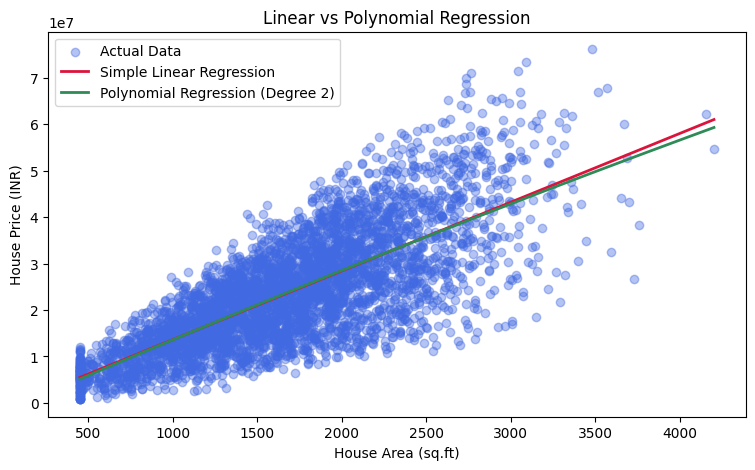

In [77]:
# Q19: Visual and Numerical Comparison of Linear and Polynomial Regression

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# ---------- Numerical Comparison ----------

# Simple Linear Regression metrics
mse_slr = mean_squared_error(y_test_slr, y_pred_slr)
mae_slr = mean_absolute_error(y_test_slr, y_pred_slr)
rmse_slr = np.sqrt(mse_slr)
r2_slr = r2_score(y_test_slr, y_pred_slr)

# Polynomial Regression metrics
mse_poly = mean_squared_error(y_test_poly, y_pred_poly)
mae_poly = mean_absolute_error(y_test_poly, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test_poly, y_pred_poly)

comparison = pd.DataFrame({
    'Metric': ['MSE', 'MAE', 'RMSE', 'R²'],
    'Simple Linear Regression': [
        mse_slr,
        mae_slr,
        rmse_slr,
        r2_slr
    ],
    'Polynomial Regression': [
        mse_poly,
        mae_poly,
        rmse_poly,
        r2_poly
    ]
})

print("Numerical Comparison:")
print(comparison)


# ---------- Visual Comparison ----------

# Create evenly spaced area values for plotting both regression lines
area_range = np.linspace(data['area_sqft'].min(),data['area_sqft'].max(),200).reshape(-1, 1)

# Linear regression predictions
linear_line = slr_model.predict(area_range)

# Polynomial regression predictions
area_range_poly = poly_features.transform(area_range)
polynomial_line = poly_model.predict(area_range_poly)

plt.figure(figsize=(9, 5))

plt.scatter(data['area_sqft'],data['house_price_inr'],alpha=0.4,label='Actual Data', color='royalblue')
plt.plot(area_range,linear_line,label='Simple Linear Regression',color='crimson',
    linewidth=2)
plt.plot(area_range,polynomial_line,label='Polynomial Regression (Degree 2)',color='seagreen',
    linewidth=2)

plt.title("Linear vs Polynomial Regression")
plt.xlabel("House Area (sq.ft)")
plt.ylabel("House Price (INR)")
plt.legend()
plt.show()

#### 🎯INSIGHT :
* Linear and polynomial results are nearly identical (R² 0.5625 vs 0.5627) — the area–price relationship is genuinely linear; extra complexity buys nothing.

### Q20. Identify signs of overfitting or underfitting.

In [41]:
# Q20: Check for Overfitting or Underfitting

# Training predictions for Polynomial Regression
y_train_pred_poly = poly_model.predict(
    X_train_poly_transformed
)

# Calculate training and testing R²
train_r2_poly = r2_score(
    y_train_poly,
    y_train_pred_poly
)

test_r2_poly = r2_score(
    y_test_poly,
    y_pred_poly
)

r2_difference = train_r2_poly - test_r2_poly

print("Polynomial Regression - Training R²:", train_r2_poly)
print("Polynomial Regression - Testing R²:", test_r2_poly)
print("R² Difference:", r2_difference)

Polynomial Regression - Training R²: 0.5724674245504779
Polynomial Regression - Testing R²: 0.5626917978136475
R² Difference: 0.009775626736830412


**Observation**

- If training R2 and testing R2 are both low, the model is **underfitting** (high bias). The simple linear model is close to this case.
- If training R2 is much higher than testing R2 (big difference), the model is **overfitting** (high variance).
- Here the difference between training and testing R2 of the polynomial model is very small, so degree 2 polynomial is
  not overfitting much. Overfitting will start if we keep increasing the degree.

#### 🎯INSIGHT : 
* Train R² (0.572) ≈ Test R² (0.563), gap < 0.01 — no overfitting
* both being low signals slight underfitting (high bias).

## ⚙️ Part G: Gradient Descent Optimization

### Q21.  Explain Gradient Descent conceptually.

##### Gradient Descent is an optimization algorithm used to find the values of model parameters that minimize the loss function.

- The algorithm starts with initial parameter values and repeatedly updates them in the direction that reduces the error. The learning rate controls the size of each update.

* The main steps are:
1. Initialize the model parameters.
2. Calculate predictions.
3. Calculate the error or loss.
4. Calculate the gradient of the loss.
5. Update the parameters.
6. Repeat the process until the model converges or the maximum number of iterations is reached.

##### Batch Gradient Descent uses the complete dataset for each update, Stochastic Gradient Descent uses one observation at a time, and Mini-Batch Gradient Descent uses a small group of observations for each update.

### Q22. Implement Batch Gradient Descent from scratch.

In [42]:
# Q22: Batch Gradient Descent from scratch

import numpy as np
import matplotlib.pyplot as plt

# Use House Area as the feature
X_gd = data['area_sqft'].values.astype(float)
y_gd = data['house_price_inr'].values.astype(float)

# Standardize X and y for stable gradient descent
X_mean = X_gd.mean()
X_std = X_gd.std()

y_mean = y_gd.mean()
y_std = y_gd.std()

X_scaled = (X_gd - X_mean) / X_std
y_scaled = (y_gd - y_mean) / y_std

m = len(X_scaled)

learning_rate = 0.01
epochs = 1000

beta0_batch = 0.0
beta1_batch = 0.0

batch_loss_history = []

for epoch in range(epochs):

    y_pred = beta0_batch + beta1_batch * X_scaled
    error = y_pred - y_scaled

    gradient_beta0 = np.mean(error)
    gradient_beta1 = np.mean(error * X_scaled)

    beta0_batch -= learning_rate * gradient_beta0
    beta1_batch -= learning_rate * gradient_beta1

    loss = np.mean(error ** 2)
    batch_loss_history.append(loss)

print("Batch Gradient Descent completed")
print("Final Beta0:", beta0_batch)
print("Final Beta1:", beta1_batch)
print("Final MSE:", batch_loss_history[-1])

Batch Gradient Descent completed
Final Beta0: 1.1137968854091849e-16
Final Beta1: 0.7554012214296654
Final MSE: 0.4293197228524156


#### 🎯INSIGHT :
* Batch GD gives the smoothest convergence and lowest final MSE (0.4293), but updates are slow — one step per full dataset.

### Q23. Implement Stochastic Gradient Descent (SGD)

In [43]:
# Q23: Stochastic Gradient Descent from scratch

learning_rate = 0.01
epochs = 1000

beta0_sgd = 0.0
beta1_sgd = 0.0

sgd_loss_history = []

for epoch in range(epochs):

    indices = np.random.permutation(m)

    for i in indices:

        xi = X_scaled[i]
        yi = y_scaled[i]

        y_pred_i = beta0_sgd + beta1_sgd * xi
        error_i = y_pred_i - yi

        beta0_sgd -= learning_rate * error_i
        beta1_sgd -= learning_rate * error_i * xi

    # Calculate loss after each epoch
    y_pred_epoch = beta0_sgd + beta1_sgd * X_scaled
    epoch_error = y_pred_epoch - y_scaled
    epoch_loss = np.mean(epoch_error ** 2)

    sgd_loss_history.append(epoch_loss)

print("Stochastic Gradient Descent completed")
print("Final Beta0:", beta0_sgd)
print("Final Beta1:", beta1_sgd)
print("Final MSE:", sgd_loss_history[-1])

Stochastic Gradient Descent completed
Final Beta0: 0.09948405008938146
Final Beta1: 0.7992555433073366
Final MSE: 0.441137140156519


#### 🎯INSIGHT : 
* SGD reaches low error in very few epochs, but the loss curve is noisy and total training time is the highest (~2s).

### Q24. Implement Mini-Batch Gradient Descent.

In [44]:
# Q24: Mini-Batch Gradient Descent from scratch

learning_rate = 0.01
epochs = 1000
batch_size = 64

beta0_mb = 0.0
beta1_mb = 0.0

mini_batch_loss_history = []

for epoch in range(epochs):

    indices = np.random.permutation(m)

    X_shuffled = X_scaled[indices]
    y_shuffled = y_scaled[indices]

    for i in range(0, m, batch_size):

        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]

        current_batch_size = len(X_batch)

        y_pred_batch = beta0_mb + beta1_mb * X_batch
        error_batch = y_pred_batch - y_batch

        gradient_beta0 = np.mean(error_batch)
        gradient_beta1 = np.mean(error_batch * X_batch)

        beta0_mb -= learning_rate * gradient_beta0
        beta1_mb -= learning_rate * gradient_beta1

    # Calculate loss after each epoch
    y_pred_epoch = beta0_mb + beta1_mb * X_scaled
    epoch_error = y_pred_epoch - y_scaled
    epoch_loss = np.mean(epoch_error ** 2)

    mini_batch_loss_history.append(epoch_loss)

print("Mini-Batch Gradient Descent completed")
print("Final Beta0:", beta0_mb)
print("Final Beta1:", beta1_mb)
print("Final MSE:", mini_batch_loss_history[-1])

Mini-Batch Gradient Descent completed
Final Beta0: 0.0022253134717850564
Final Beta1: 0.7552247946115457
Final MSE: 0.42932471748491297


#### 🎯INSIGHT : 
* Mini-Batch GD matches Batch GD's final MSE (0.4293) with much less time than SGD .
* the best balance of speed and stability.

### Q25. Compare convergence behavior and training time of all three methods.

          Method  Final MSE  Training Time (seconds)
0       Batch GD   0.507332                 0.035727
1  Stochastic GD   0.431393                 1.991507
2  Mini-Batch GD   0.429320                 0.752934


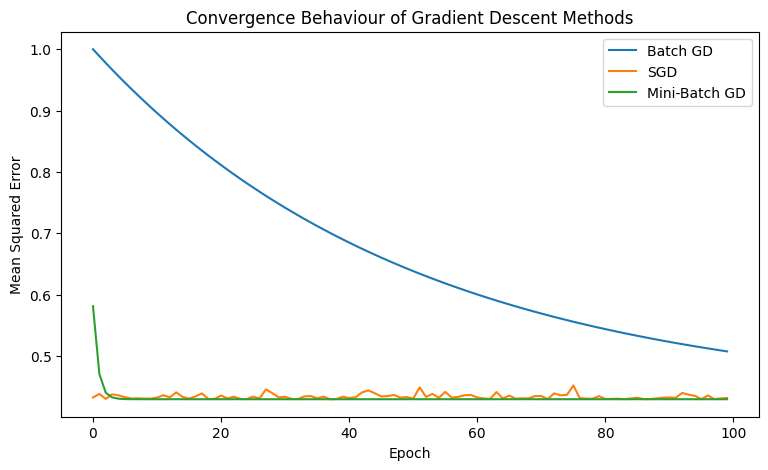

In [45]:
# Q25: Compare convergence behaviour and training time of all three methods

import time

epochs_compare = 100   # smaller number of epochs so all three methods run in fair time


# ---------- Batch Gradient Descent ----------
start_time = time.time()

beta0 = 0.0
beta1 = 0.0
batch_history = []

for epoch in range(epochs_compare):

    error = (beta0 + beta1 * X_scaled) - y_scaled

    beta0 -= learning_rate * np.mean(error)
    beta1 -= learning_rate * np.mean(error * X_scaled)

    batch_history.append(np.mean(error ** 2))

batch_time = time.time() - start_time


# ---------- Stochastic Gradient Descent ----------
start_time = time.time()

beta0 = 0.0
beta1 = 0.0
sgd_history = []

for epoch in range(epochs_compare):

    for i in np.random.permutation(m):

        error = (beta0 + beta1 * X_scaled[i]) - y_scaled[i]

        beta0 -= learning_rate * error
        beta1 -= learning_rate * error * X_scaled[i]

    error_all = (beta0 + beta1 * X_scaled) - y_scaled
    sgd_history.append(np.mean(error_all ** 2))

sgd_time = time.time() - start_time


# ---------- Mini-Batch Gradient Descent ----------
start_time = time.time()

beta0 = 0.0
beta1 = 0.0
mini_batch_history = []

for epoch in range(epochs_compare):

    indices = np.random.permutation(m)
    X_shuffled = X_scaled[indices]
    y_shuffled = y_scaled[indices]

    for i in range(0, m, batch_size):

        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]

        error = (beta0 + beta1 * X_batch) - y_batch

        beta0 -= learning_rate * np.mean(error)
        beta1 -= learning_rate * np.mean(error * X_batch)

    error_all = (beta0 + beta1 * X_scaled) - y_scaled
    mini_batch_history.append(np.mean(error_all ** 2))

mini_batch_time = time.time() - start_time


# ---------- Comparison Table ----------
comparison_gd = pd.DataFrame({
    'Method': ['Batch GD', 'Stochastic GD', 'Mini-Batch GD'],
    'Final MSE': [batch_history[-1], sgd_history[-1], mini_batch_history[-1]],
    'Training Time (seconds)': [batch_time, sgd_time, mini_batch_time]
})

print(comparison_gd)


# ---------- Convergence Plot ----------
plt.figure(figsize=(9, 5))

plt.plot(batch_history, label="Batch GD")
plt.plot(sgd_history, label="SGD")
plt.plot(mini_batch_history, label="Mini-Batch GD")

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Convergence Behaviour of Gradient Descent Methods")
plt.legend()
plt.show()

#### 🎯INSIGHT :
* Batch GD = fastest per epoch but needs more epochs; SGD = fast convergence, slowest overall; Mini-Batch = the practical winner.

**Observation**

- **Batch GD** takes the least time per epoch and its curve is very smooth, but it needs more epochs to reach a low error.
- **Stochastic GD** reaches a low error in very few epochs because it updates the parameters for every row, but it takes
  the highest training time and the curve is a little noisy.
- **Mini-Batch GD** converges almost as fast as SGD but takes much less time, so it gives the best balance and is the
  method used in practice.

## 🔍 Part H: Bias–Variance & Model Diagnostics

### Q26. Analyze bias and variance across:
* Simple Linear Regression
* Multiple Linear Regression
* Polynomial Regression

In [46]:
# Q26: Bias-Variance Analysis

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

# -----------------------------
# Define the models
# -----------------------------

# Simple Linear Regression
slr = LinearRegression()

# Multiple Linear Regression
mlr = LinearRegression()

# Polynomial Regression - Degree 2
poly = Pipeline([
    ('polynomial_features', PolynomialFeatures(degree=2)),
    ('linear_regression', LinearRegression())
])


# -----------------------------
# Training data
# -----------------------------

X_slr_all = data[['area_sqft']]
X_mlr_all = data[
    [
        'area_sqft',
        'bedrooms',
        'bathrooms',
        'location_score',
        'age_years'
    ]
]
y_all = data['house_price_inr']


# -----------------------------
# Fit models
# -----------------------------

slr.fit(X_slr_all, y_all)
mlr.fit(X_mlr_all, y_all)
poly.fit(X_slr_all, y_all)


# -----------------------------
# Training R²
# -----------------------------

train_r2_slr = r2_score(y_all, slr.predict(X_slr_all))
train_r2_mlr = r2_score(y_all, mlr.predict(X_mlr_all))
train_r2_poly = r2_score(y_all, poly.predict(X_slr_all))


# -----------------------------
# 5-Fold Cross Validation
# -----------------------------

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

slr_cv = cross_val_score(
    slr,
    X_slr_all,
    y_all,
    cv=cv,
    scoring='r2'
)

mlr_cv = cross_val_score(
    mlr,
    X_mlr_all,
    y_all,
    cv=cv,
    scoring='r2'
)

poly_cv = cross_val_score(
    poly,
    X_slr_all,
    y_all,
    cv=cv,
    scoring='r2'
)


# -----------------------------
# Create comparison table
# -----------------------------

bias_variance_table = pd.DataFrame({
    'Model': [
        'Simple Linear Regression',
        'Multiple Linear Regression',
        'Polynomial Regression'
    ],
    'Training R²': [
        train_r2_slr,
        train_r2_mlr,
        train_r2_poly
    ],
    'Mean CV R²': [
        slr_cv.mean(),
        mlr_cv.mean(),
        poly_cv.mean()
    ],
    'CV R² Std': [
        slr_cv.std(),
        mlr_cv.std(),
        poly_cv.std()
    ]
})

print("Bias-Variance Analysis")
print("----------------------")
print(bias_variance_table)

print("\nCross-validation scores:")
print("SLR:", slr_cv)
print("MLR:", mlr_cv)
print("Polynomial:", poly_cv)

Bias-Variance Analysis
----------------------
                        Model  Training R²  Mean CV R²  CV R² Std
0    Simple Linear Regression     0.570680    0.569339   0.010146
1  Multiple Linear Regression     0.921091    0.920621   0.003340
2       Polynomial Regression     0.570839    0.569245   0.009944

Cross-validation scores:
SLR: [0.56251996 0.5676588  0.55508619 0.57940568 0.58202323]
MLR: [0.91609027 0.92520902 0.92154494 0.91759247 0.92266819]
Polynomial: [0.5626918  0.56689804 0.55551069 0.57979704 0.58132627]


#### 🎯INSIGHT :
* SLR and Poly show high bias (CV R² ≈ 0.57) but low variance (CV std ≈ 0.01)
* MLR shows low bias and low variance (CV R² ≈ 0.921, std ≈ 0.003)
*  it is the best-balanced model for this data.

### Q27. Explain how model complexity affects prediction error. 

- When the model is **too simple** (only one feature), it cannot capture the real pattern. Bias is high and both
  training and testing error are high. This is underfitting.
- When we **increase complexity** (more features, polynomial terms), bias reduces and training error keeps decreasing.
- If the model becomes **too complex**, it starts learning the noise of the training data. Variance becomes high, so
  training error is very low but testing error increases. This is overfitting.

Total error = Bias² + Variance + Irreducible error. So the error first decreases and then increases with complexity
(U-shape curve). The best model is the one at the bottom of this curve.

### Q28. Identify which model best balances bias and variance.

In [47]:
# Q28: Identify the model with the best bias-variance balance

results = bias_variance_table.copy()

# Calculate the gap between training and cross-validation R²
results['Train-CV Gap'] = (
    results['Training R²'] - results['Mean CV R²']
)

print("Model Diagnostics")
print("-----------------")
print(results)

# Best validation performance
best_cv_model = results.loc[
    results['Mean CV R²'].idxmax(),
    'Model'
]

print("\nBest validation performance:", best_cv_model)

# Most consistent model
most_consistent_model = results.loc[
    results['CV R² Std'].idxmin(),
    'Model'
]

print("Most consistent CV performance:", most_consistent_model)

Model Diagnostics
-----------------
                        Model  Training R²  Mean CV R²  CV R² Std  \
0    Simple Linear Regression     0.570680    0.569339   0.010146   
1  Multiple Linear Regression     0.921091    0.920621   0.003340   
2       Polynomial Regression     0.570839    0.569245   0.009944   

   Train-CV Gap  
0      0.001342  
1      0.000470  
2      0.001595  

Best validation performance: Multiple Linear Regression
Most consistent CV performance: Multiple Linear Regression


In [48]:
final_table = pd.DataFrame({
    'Model': [
        'Simple Linear Regression',
        'Multiple Linear Regression',
        'Polynomial Regression (Degree 2)'
    ],
    'R2 Score': [r2_slr, r2_mlr, r2_poly],
    'RMSE': [rmse_slr, rmse_mlr, rmse_poly],
    'MAE': [mae_slr, mae_mlr, mae_poly]
})

print(final_table)

                              Model  R2 Score          RMSE           MAE
0          Simple Linear Regression  0.562520  8.184697e+06  6.294594e+06
1        Multiple Linear Regression  0.916090  3.584509e+06  2.641320e+06
2  Polynomial Regression (Degree 2)  0.562692  8.183089e+06  6.292395e+06
